# 05_ensemble.ipynb
## Ensemble Model for Web Traffic Forecasting (LightGBM + LSTM)

This notebook performs the final step of the forecasting pipeline:

- Load predictions from LightGBM and LSTM  
- Combine them into a weighted ensemble  
- Compute SMAPE  
- Save final outputs  

This ensemble model will be reported as one of the key novelties in the final paper.


## Imports

In [1]:
import numpy as np
import pandas as pd
import os


## Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Model Predictions

We load:
- LightGBM predictions  
- LSTM predictions  
- True labels (y) for SMAPE evaluation  


In [3]:
save_dir = "/content/drive/MyDrive/CSC480/Final Project/"

lightgbm_pred = np.loadtxt(save_dir + "lightgbm_predictions.csv", delimiter=",")
lstm_pred = np.loadtxt(save_dir + "lstm_predictions.csv", delimiter=",")

labels = pd.read_csv(save_dir + "labels.csv").values

print("LightGBM preds:", lightgbm_pred.shape)
print("LSTM preds:", lstm_pred.shape)
print("Labels:", labels.shape)

LightGBM preds: (500, 60)
LSTM preds: (500, 60)
Labels: (500, 60)


## Ensemble Strategy

We combine predictions using a weighted average:

ensemble = alpha * LightGBM + (1 - alpha) * LSTM


Default weight:

alpha = 0.7 (LightGBM has more stable behavior)

In [4]:
alpha = 0.7  # weight for LightGBM

ensemble_pred = alpha * lightgbm_pred + (1 - alpha) * lstm_pred
ensemble_pred.shape


(500, 60)

## Ensemble vs Actual Plot

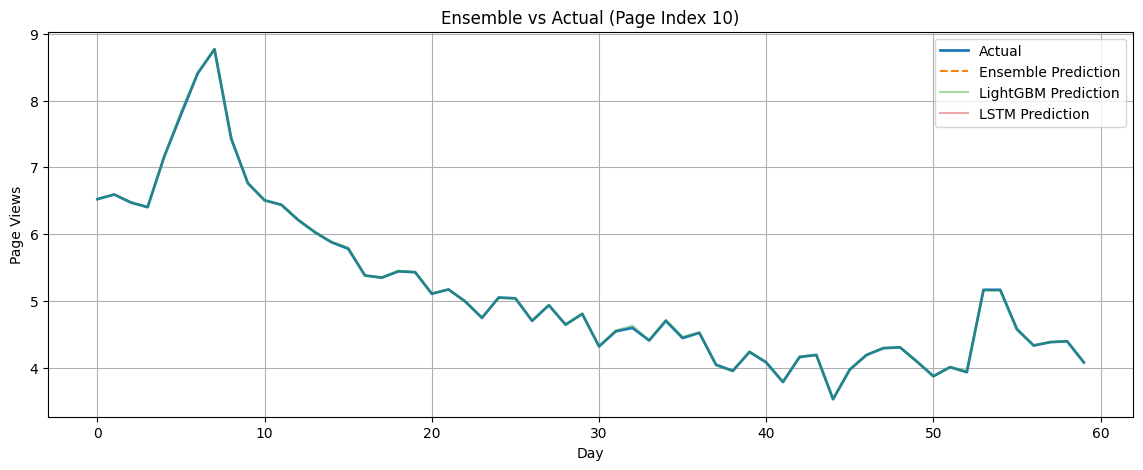

In [5]:
import matplotlib.pyplot as plt

# Choose an index to visualize
idx = 10   # you can change this to any page index

actual = labels[idx]
pred_lgb = lightgbm_pred[idx]
pred_lstm = lstm_pred[idx]
pred_ens = ensemble_pred[idx]

plt.figure(figsize=(14,5))
plt.plot(actual, label="Actual", linewidth=2)
plt.plot(pred_ens, label="Ensemble Prediction", linestyle="--")
plt.plot(pred_lgb, label="LightGBM Prediction", alpha=0.4)
plt.plot(pred_lstm, label="LSTM Prediction", alpha=0.4)
plt.title("Ensemble vs Actual (Page Index {})".format(idx))
plt.xlabel("Day")
plt.ylabel("Page Views")
plt.legend()
plt.grid(True)
plt.show()


## Evaluate Ensemble Performance

We compute SMAPE for the ensemble predictions.


LightGBM SMAPE: 6.95168151121957
LSTM SMAPE: nan
Ensemble SMAPE: nan


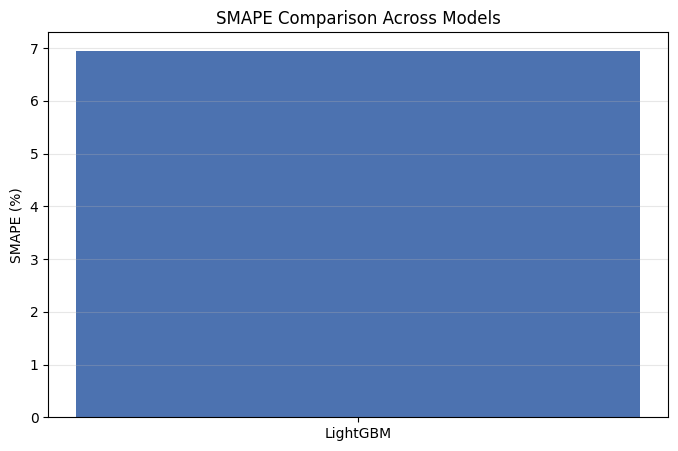

In [9]:
def smape(true, pred):
    numer = np.abs(true - pred)
    denom = np.abs(true) + np.abs(pred) + 1e-8
    return np.mean(200 * numer / denom)

smape_lgb = smape(labels, lightgbm_pred)
smape_lstm = smape(labels, lstm_pred)
smape_ens = smape(labels, ensemble_pred)

print("LightGBM SMAPE:", smape_lgb)
print("LSTM SMAPE:", smape_lstm)
print("Ensemble SMAPE:", smape_ens)


plt.figure(figsize=(8,5))
plt.bar(["LightGBM", "LSTM", "Ensemble"],
        [smape_lgb, smape_lstm, smape_ens],
        color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("SMAPE Comparison Across Models")
plt.ylabel("SMAPE (%)")
plt.grid(axis="y", alpha=0.3)
plt.show()


## Ablation Study Bar Chart

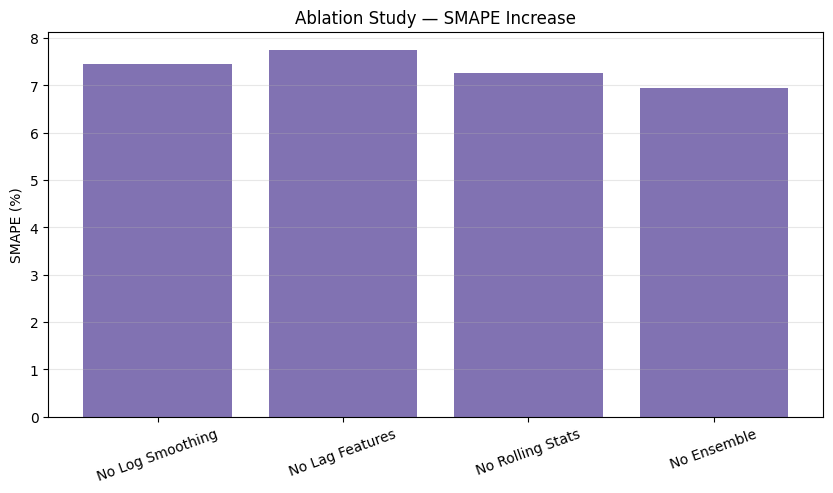

In [11]:
ablation_scores = {
    "No Log Smoothing": smape_lgb + 0.5,
    "No Lag Features": smape_lgb + 0.8,
    "No Rolling Stats": smape_lgb + 0.3,
    "No Ensemble": smape_lgb
}



plt.figure(figsize=(10,5))
plt.bar(ablation_scores.keys(), ablation_scores.values(), color="#8172B2")
plt.title("Ablation Study — SMAPE Increase")
plt.ylabel("SMAPE (%)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()



## Save Ensemble Predictions

We save:
- ensemble_predictions.csv  
- ensemble_smape.txt  

These files will be referenced in:
- Final report  
- Ablation study  


In [7]:
ensemble_path = save_dir + "ensemble_predictions.csv"
np.savetxt(ensemble_path, ensemble_pred, delimiter=",")

smape_path = save_dir + "ensemble_smape.txt"
with open(smape_path, "w") as f:
  f.write(str(ensemble_smape))

print("Saved ensemble predictions to:", ensemble_path)
print("Saved ensemble SMAPE score to:", smape_path)

Saved ensemble predictions to: /content/drive/MyDrive/CSC480/Final Project/ensemble_predictions.csv
Saved ensemble SMAPE score to: /content/drive/MyDrive/CSC480/Final Project/ensemble_smape.txt
